# Network-wise Dice similarity between group parcellations

This notebook visualizes the network correspondence tables used for the task/rest group parcellation comparisons. Group parcellations are trained by the root [`train_group.py`](../../train_group.py) workflow; this notebook uses the precomputed network-wise Dice tables in `results/3.task_rest_fusion`.

The heatmap styling follows the CBIG network correspondence plotting routine (`visualize_overlap_lib.draw_overlap_mat`): greedy column matching to make the matrix approximately diagonal, and white stars for significant cells (`p < 0.05`). In paper, we didn't perform this matching process but manually adjusted the row and columns in order to make sure the two networks at the diagonal are one-to-one correpsonding.

Group task-based parcellation HBP17 (2a), `replication/group_parcellations/17Networks/HBP17_TASK_networks.dlabel.nii`

Dice overlapping:
- Table S3: Figure panel 2c, `HBP17REST` vs `MSHBM17`
- Table S6: Supplementary figure panel 3c, `HBP17REST` vs `YEO17`
- Table S7: Main figure panel 3c, `HBP17REST` vs `HBP17TASK`
- Table S8: Main figure panel 4b, `HBP17FUSION` vs `HBP17REST`
- Table S9: Main figure panel 4c, `HBP17FUSION` vs `HBP17TASK`


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import scipy.io as spio
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.linewidth"] = 1.5


In [2]:
def find_repo_root(start=Path.cwd()):
    for path in [start, *start.parents]:
        if (path / "train_group.py").exists() and (path / "results").exists():
            return path
    raise FileNotFoundError("Could not locate the IndividualParcellation repo root.")


REPO_ROOT = find_repo_root()
TABLE_DIR = REPO_ROOT / "results" / "3.task_rest_fusion"
MSHBM_17NETWORK_DIR = REPO_ROOT / "replication" / "MSHBM_17networks"
OUTPUT_DIR = TABLE_DIR / "figures"
SAVE_FIGURES = False

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_GROUP_SCRIPT = REPO_ROOT / "train_group.py"
TABLE_DIR

PosixPath('/home/dzhi/Workspace/IndividualParcellation/results/3.task_rest_fusion')

In [3]:
TABLE_INFO = [
    {
        "table": "Table S3",
        "panel": "Figure 2c",
        "comparison": "HBP17REST vs MSHBM17",
        "file": "Table_S3_network_correspondence_HBP17REST_vs_MSHBM17.csv",
    },
    {
        "table": "Table S6",
        "panel": "Supplementary Figure 3c",
        "comparison": "HBP17REST vs YEO17",
        "file": "Table_S6_network_correspondence_HBP17REST_vs_YEO17.csv",
    },
    {
        "table": "Table S7",
        "panel": "Figure 3c",
        "comparison": "HBP17REST vs HBP17TASK",
        "file": "Table_S7_network_correspondence_HBP17REST_vs_HBP17TASK.csv",
    },
    {
        "table": "Table S8",
        "panel": "Figure 4b",
        "comparison": "HBP17FUSION vs HBP17REST",
        "file": "Table_S8_network_correspondence_HBP17FUSION_vs_HBP17REST.csv",
    },
    {
        "table": "Table S9",
        "panel": "Figure 4c",
        "comparison": "HBP17FUSION vs HBP17TASK",
        "file": "Table_S9_network_correspondence_HBP17FUSION_vs_HBP17TASK.csv",
    },
]

The table cells are stored as strings like `0.5794
(p=0.0010)`. The parser below extracts both the leading Dice coefficient and the p-value, then drops empty padding rows/columns, including the extra unnamed fields in Table S7.


In [4]:
def clean_label(label):
    if pd.isna(label):
        return None
    label = str(label).strip()
    if not label or label.startswith("Unnamed:"):
        return None
    return label


def extract_dice(cell):
    if pd.isna(cell):
        return np.nan
    text = str(cell).strip()
    if not text:
        return np.nan
    match = re.search(r"[-+]?\d*\.\d+|[-+]?\d+", text)
    return float(match.group(0)) if match else np.nan


def extract_p_value(cell):
    if pd.isna(cell):
        return np.nan
    text = str(cell)
    match = re.search(r"p\s*=\s*([-+]?\d*\.\d+|[-+]?\d+)", text)
    return float(match.group(1)) if match else np.nan


def load_overlap_matrices(csv_path):
    raw = pd.read_csv(csv_path, dtype=str)
    row_name_col = raw.columns[0]
    raw = raw.rename(columns={row_name_col: "network"})
    raw["network"] = raw["network"].map(clean_label)
    raw = raw.loc[raw["network"].notna()].copy()

    valid_cols = [col for col in raw.columns[1:] if clean_label(col) is not None]
    raw = raw[["network", *valid_cols]].set_index("network")
    raw.columns = [clean_label(col) for col in raw.columns]

    dice = raw.apply(lambda col: col.map(extract_dice))
    p_values = raw.apply(lambda col: col.map(extract_p_value))

    valid_rows = ~dice.isna().all(axis=1)
    valid_cols = ~dice.isna().all(axis=0)
    dice = dice.loc[valid_rows, valid_cols]
    p_values = p_values.loc[dice.index, dice.columns]
    return dice, p_values


In [5]:
dice_matrices = {}
pvalue_matrices = {}
summary_rows = []

for item in TABLE_INFO:
    dice, p_values = load_overlap_matrices(TABLE_DIR / item["file"])
    dice_matrices[item["table"]] = dice
    pvalue_matrices[item["table"]] = p_values
    summary_rows.append({
        "table": item["table"],
        "panel": item["panel"],
        "comparison": item["comparison"],
        "shape": f"{dice.shape[0]} x {dice.shape[1]}",
        "max_dice": float(np.nanmax(dice.values)),
        "significant_cells": int(np.nansum(p_values.values < 0.05)),
    })

pd.DataFrame(summary_rows)


,table,panel,comparison,shape,max_dice,significant_cells
0,Table S3,Figure 2c,HBP17REST vs MSHBM17,17 x 17,0.9246,21
1,Table S6,Supplementary Figure 3c,HBP17REST vs YEO17,17 x 17,0.8875,27
2,Table S7,Figure 3c,HBP17REST vs HBP17TASK,17 x 17,0.7141,31
3,Table S8,Figure 4b,HBP17FUSION vs HBP17REST,17 x 17,0.8973,20
4,Table S9,Figure 4c,HBP17FUSION vs HBP17TASK,17 x 17,0.9097,25


In [6]:
def pair_match(overlap_mat):
    """Greedy column matching used by CBIG's draw_overlap_mat()."""
    overlap_mat = np.asarray(overlap_mat, dtype=float)
    if np.min(overlap_mat.shape) == 1:
        return np.argsort(-overlap_mat.flatten()).tolist()

    if overlap_mat.shape[0] > overlap_mat.shape[1]:
        work = overlap_mat[:overlap_mat.shape[1], :].copy()
    else:
        work = overlap_mat.copy()

    work = np.nan_to_num(work, nan=-np.inf)
    order_idx = []
    for i in range(work.shape[0]):
        row = work[i, :]
        if np.all(np.isneginf(row)):
            remaining = [j for j in range(work.shape[1]) if j not in order_idx]
            if not remaining:
                break
            match_idx = remaining[0]
        else:
            match_idx = int(np.argmax(row))
        order_idx.append(match_idx)
        work[:, match_idx] = -np.inf

    if overlap_mat.shape[0] < overlap_mat.shape[1]:
        remain_idx = [i for i in np.arange(overlap_mat.shape[1])
                      if i not in order_idx]
        order_idx = list(order_idx) + list(remain_idx)
    return order_idx


def reorder_by_pair_match(dice, p_values):
    order_idx = pair_match(dice.values)
    return dice.iloc[:, order_idx], p_values.iloc[:, order_idx]


def plot_dice_matrix(dice, p_values, title, ax=None, minv=0, maxv=1,
                     p_threshold=0.05):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 7))

    dice_plot, p_plot = reorder_by_pair_match(dice, p_values)
    im = sns.heatmap(
        data=dice_plot,
        ax=ax,
        cmap="rocket",
        square=True,
        vmin=minv,
        vmax=maxv,
        linewidths=0.05,
        linecolor="white",
        xticklabels=dice_plot.columns,
        yticklabels=dice_plot.index,
        cbar=False,
    )

    for i in range(dice_plot.shape[0]):
        for j in range(dice_plot.shape[1]):
            if p_plot.iloc[i, j] < p_threshold:
                im.text(j + 0.5, i + 0.5, "*", fontsize=14,
                        ha="center", va="center", color="white")

    frame_len = 3.5
    ax.axhline(y=0, color="k", linewidth=frame_len)
    ax.axhline(y=dice_plot.shape[0], color="k", linewidth=frame_len)
    ax.axvline(x=0, color="k", linewidth=frame_len)
    ax.axvline(x=dice_plot.shape[1], color="k", linewidth=frame_len)

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")
    ax.tick_params(axis="x", which="major", labelsize=12,
                   labelrotation=90, pad=10)
    ax.tick_params(axis="y", which="major", labelsize=12,
                   labelrotation=0, pad=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=72)

    mappable = im.collections[0]
    cb = plt.colorbar(
        mappable,
        ax=ax,
        orientation="horizontal",
        label="Dice overlap",
        aspect=35.5,
        fraction=0.025,
        pad=0.08,
    )
    cb.outline.set_linewidth(1.5)
    cb.outline.set_color("black")
    cb.ax.locator_params(nbins=10)
    cb.ax.tick_params(labelsize=10, width=1.5)
    return ax


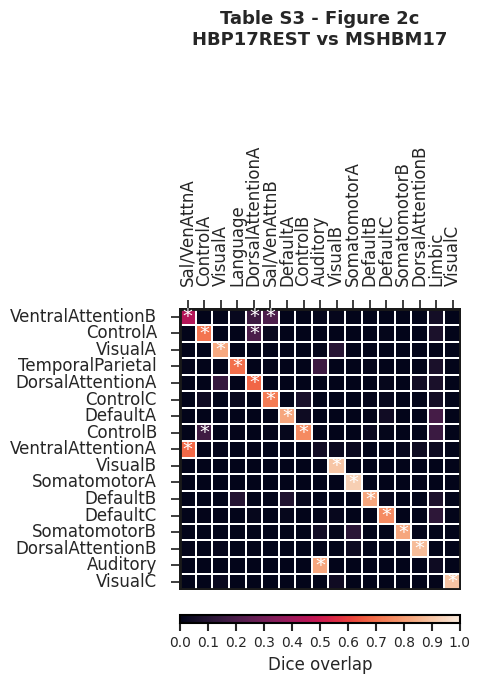

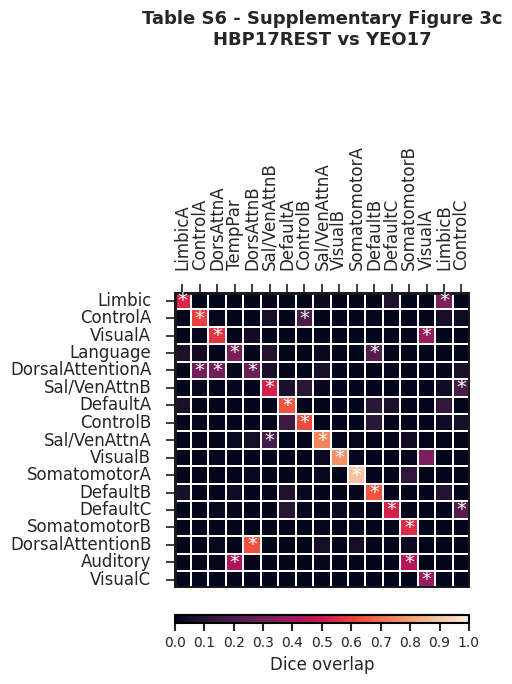

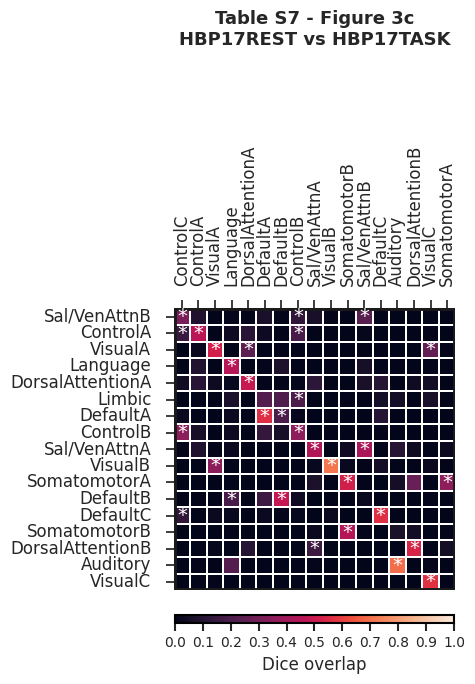

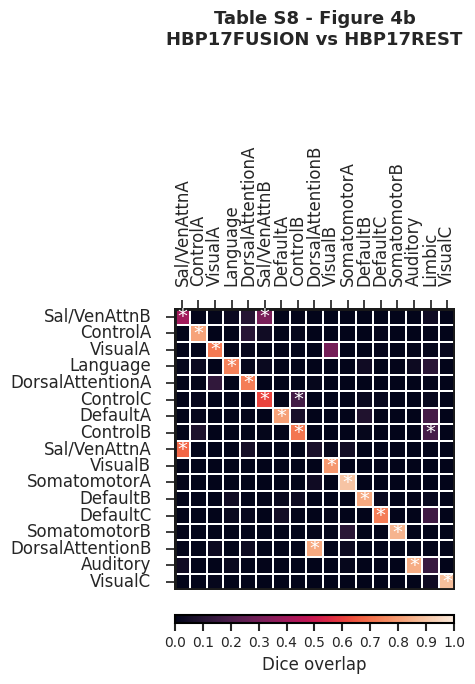

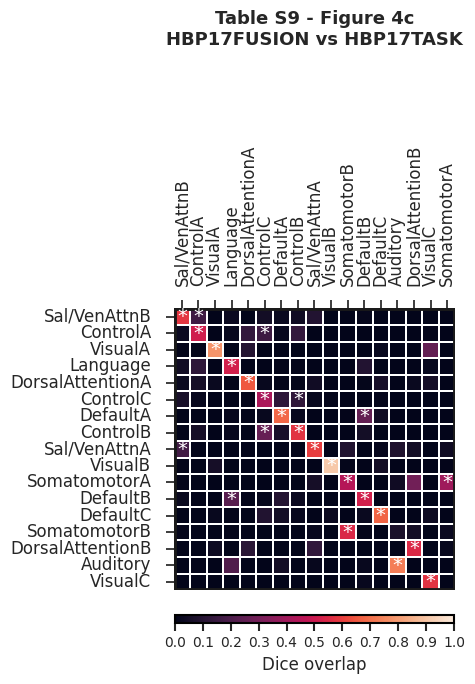

In [7]:
for item in TABLE_INFO:
    dice = dice_matrices[item["table"]]
    p_values = pvalue_matrices[item["table"]]
    fig, ax = plt.subplots(figsize=(7, 7))
    title = (f"{item['table']} - {item['panel']}" + "\n" +
             f"{item['comparison']}")
    plot_dice_matrix(dice, p_values, title, ax=ax)
    plt.tight_layout()

    if SAVE_FIGURES:
        out_file = OUTPUT_DIR / f"{Path(item['file']).stem}_dice_matrix.png"
        fig.savefig(out_file, dpi=300, bbox_inches="tight")
    plt.show()


# Figure 3d: unimodal vs heteromodal Dice overlap

The table `uni_hetero.tsv` stores one Dice overlap value per network for the HBP17REST vs HBP17TASK correspondence. The boxplot summarizes Dice overlap for unimodal and heteromodal networks, with individual network points colored by the MSHBM17 network color table from `replication/MSHBM_17networks`.


In [8]:
UNI_HETERO_FILE = TABLE_DIR / "uni_hetero.tsv"


def load_mshbm17_palette():
    labels = spio.loadmat(MSHBM_17NETWORK_DIR / "17network_labels.mat")["network_name"]
    network_names = [labels[0][i][0] for i in range(17)]
    colors = spio.loadmat(MSHBM_17NETWORK_DIR / "group.mat")["colors"]
    colors = colors[1:, :] / 255

    # Match names used in the paper tables to the Kong/MSHBM17 metadata labels.
    name_alias = {
        "VentralAttentionA": "Sal/VenAttnA",
        "VentralAttentionB": "Sal/VenAttnB",
        "TemporalParietal": "Language",
    }
    palette = {name_alias.get(name, name): colors[i]
               for i, name in enumerate(network_names)}
    table_network_names = [name_alias.get(name, name) for name in network_names]
    return table_network_names, palette


network_names, palette_dict = load_mshbm17_palette()
df_uni_hetero = pd.read_csv(UNI_HETERO_FILE, sep="\t")
df_uni_hetero["model"] = pd.Categorical(df_uni_hetero["model"],
                                         categories=["uni", "hetero"],
                                         ordered=True)
df_sorted = df_uni_hetero.sort_values(["model", "networks"]).copy()
df_sorted


,dice,networks,model
15,0.6916,Auditory,uni
10,0.3590,SomatomotorA,uni
13,0.4437,SomatomotorB,uni
2,0.5220,VisualA,uni
9,0.7141,VisualB,uni
16,0.5683,VisualC,uni
1,0.4586,ControlA,hetero
7,0.3587,ControlB,hetero
5,0.0006,ControlC,hetero
6,0.5640,DefaultA,hetero


/tmp/ipykernel_698597/2279806766.py:38: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(["Heteromodal", "Unimodal"], fontsize=13)


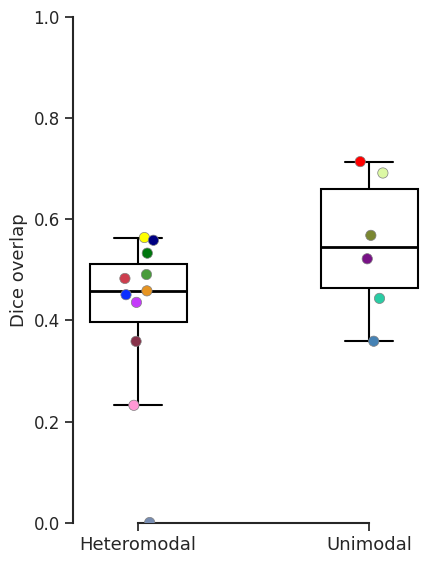

In [9]:
x_order = ["hetero", "uni"]
model_to_x = {model: i for i, model in enumerate(x_order)}
rng = np.random.default_rng(42)

fig, ax = plt.subplots(figsize=(4.6, 5.8))
sns.boxplot(
    data=df_sorted,
    x="model",
    y="dice",
    order=x_order,
    width=0.42,
    showfliers=False,
    color="white",
    ax=ax,
    boxprops={"edgecolor": "black", "linewidth": 1.5},
    whiskerprops={"color": "black", "linewidth": 1.5},
    capprops={"color": "black", "linewidth": 1.5},
    medianprops={"color": "black", "linewidth": 2.0},
)

for model in x_order:
    sub_df = df_sorted[df_sorted["model"] == model]
    base_x = model_to_x[model]
    jitter = rng.uniform(-0.07, 0.07, size=len(sub_df))
    x_pos = base_x + jitter
    point_colors = [palette_dict.get(network, (0.65, 0.65, 0.65))
                    for network in sub_df["networks"]]
    ax.scatter(
        x_pos,
        sub_df["dice"],
        c=point_colors,
        s=55,
        edgecolor="gray",
        linewidth=0.5,
        zorder=5,
    )

ax.set_xticklabels(["Heteromodal", "Unimodal"], fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Dice overlap", fontsize=13)
ax.set_ylim(0, 1)
ax.tick_params(axis="y", labelsize=12)
sns.despine(ax=ax, trim=True)
plt.tight_layout()

if SAVE_FIGURES:
    out_file = OUTPUT_DIR / "Figure_3d_uni_hetero_dice_boxplot.png"
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
plt.show()
